# YOLO Ensemble Theft Detection - Analysis & Visualization

## Comprehensive Analysis Notebook

This notebook provides:
- Dataset analysis and statistics
- Visualization of class distributions
- Bounding box analysis
- Sample visualization
- Model performance analysis
- Ensemble predictions visualization

**Author:** Senior CV & MLOps Engineer  
**Project:** Retail Theft Detection  
**Framework:** YOLOv8 Ensemble

## 1. Setup and Imports

In [1]:
!nvidia-smi

Tue Jan 20 21:07:37 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 566.07                 Driver Version: 566.07         CUDA Version: 12.7     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                  Driver-Model | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 3050 ...  WDDM  |   00000000:01:00.0 Off |                  N/A |
| N/A   44C    P8             11W /   30W |       0MiB /   4096MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
import sys
import json
import yaml
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from collections import Counter, defaultdict
from IPython.display import display, HTML

# Add src to path
sys.path.insert(0, str(Path.cwd() / 'src'))

# Set visualization style
sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 100
plt.rcParams['figure.figsize'] = (12, 6)

print("✓ Imports successful")

✓ Imports successful


## 2. Load Configuration

In [3]:
# Load configuration
config_path = Path('config/config.yaml')

with open(config_path, 'r') as f:
    config = yaml.safe_load(f)

# Extract key parameters
CLASS_NAMES = config['dataset']['classes']
NUM_CLASSES = len(CLASS_NAMES)
PRIORITY_CLASS = config['dataset']['priority_class']

print(f"Number of classes: {NUM_CLASSES}")
print(f"Class names: {CLASS_NAMES}")
print(f"Priority class: {PRIORITY_CLASS}")

# Display configuration
print("\nConfiguration loaded successfully")

Number of classes: 6
Class names: ['Customer-Bagpack', 'Product', 'Product-Picked', 'Shopping-Cart', 'normal', 'theft']
Priority class: theft

Configuration loaded successfully


## 3. Dataset Statistics

In [4]:
def analyze_dataset(images_dir, labels_dir):
    """Analyze dataset and return statistics"""
    
    images_dir = Path(images_dir)
    labels_dir = Path(labels_dir)
    
    # Get image files
    image_files = list(images_dir.glob('*.jpg')) + list(images_dir.glob('*.png'))
    
    # Statistics
    stats = {
        'total_images': len(image_files),
        'total_annotations': 0,
        'class_distribution': Counter(),
        'bbox_widths': [],
        'bbox_heights': [],
        'bbox_areas': [],
        'image_resolutions': []
    }
    
    # Analyze each image
    for img_path in image_files:
        # Image resolution
        img = cv2.imread(str(img_path))
        if img is not None:
            h, w = img.shape[:2]
            stats['image_resolutions'].append((w, h))
        
        # Annotations
        label_path = labels_dir / f"{img_path.stem}.txt"
        if label_path.exists():
            with open(label_path, 'r') as f:
                for line in f:
                    parts = line.strip().split()
                    if len(parts) >= 5:
                        class_id = int(parts[0])
                        width = float(parts[3])
                        height = float(parts[4])
                        
                        stats['total_annotations'] += 1
                        stats['class_distribution'][class_id] += 1
                        stats['bbox_widths'].append(width)
                        stats['bbox_heights'].append(height)
                        stats['bbox_areas'].append(width * height)
    
    return stats

# Set your dataset path here
# Set your dataset path here
DATASET_IMAGES = Path(r'C:\Users\EMAD AWAD\Downloads\cc-tv-footage-annotation-b8-lcysc b1.v2-download_data.yolov8\train\images')
DATASET_LABELS = Path(r'C:\Users\EMAD AWAD\Downloads\cc-tv-footage-annotation-b8-lcysc b1.v2-download_data.yolov8\train\labels')


# Analyze dataset
if DATASET_IMAGES.exists() and DATASET_LABELS.exists():
    dataset_stats = analyze_dataset(DATASET_IMAGES, DATASET_LABELS)
    
    print(f"Total Images: {dataset_stats['total_images']}")
    print(f"Total Annotations: {dataset_stats['total_annotations']}")
    print(f"Avg Annotations per Image: {dataset_stats['total_annotations'] / dataset_stats['total_images']:.2f}")
else:
    print("⚠ Dataset not found. Please run the pipeline first.")
    dataset_stats = None

Total Images: 2095
Total Annotations: 7076
Avg Annotations per Image: 3.38


## 4. Class Distribution Analysis


Class Distribution:


,Class,Count,Percentage
0,Customer-Bagpack,543,7.67%
1,Product,751,10.61%
2,Product-Picked,742,10.49%
3,Shopping-Cart,153,2.16%
4,normal,4449,62.87%
5,theft,438,6.19%


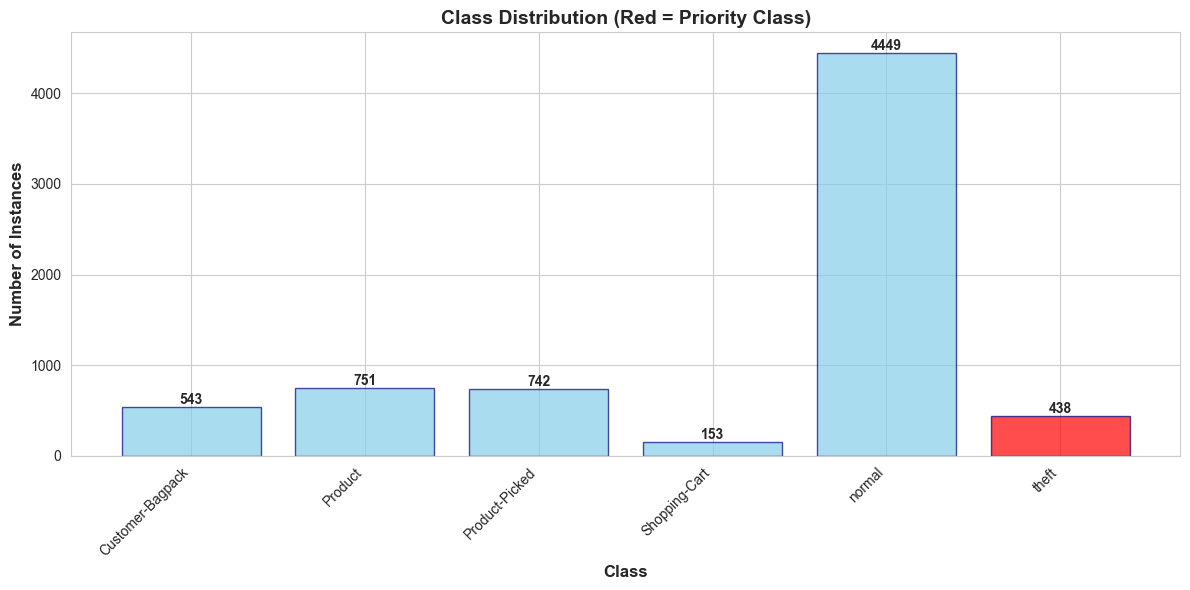

In [5]:
if dataset_stats:
    # Create DataFrame
    class_dist = dataset_stats['class_distribution']
    
    df_classes = pd.DataFrame([
        {'Class': CLASS_NAMES[class_id], 'Count': count, 'Percentage': count / dataset_stats['total_annotations'] * 100}
        for class_id, count in sorted(class_dist.items())
    ])
    
    # Display table
    print("\nClass Distribution:")
    display(df_classes.style.format({'Percentage': '{:.2f}%'}).background_gradient(subset=['Count'], cmap='Blues'))
    
    # Plot
    fig, ax = plt.subplots(figsize=(12, 6))
    bars = ax.bar(df_classes['Class'], df_classes['Count'], 
                   color=['red' if c == PRIORITY_CLASS else 'skyblue' for c in df_classes['Class']],
                   edgecolor='navy', alpha=0.7)
    
    # Add value labels
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{int(height)}',
                ha='center', va='bottom', fontweight='bold')
    
    ax.set_xlabel('Class', fontsize=12, fontweight='bold')
    ax.set_ylabel('Number of Instances', fontsize=12, fontweight='bold')
    ax.set_title('Class Distribution (Red = Priority Class)', fontsize=14, fontweight='bold')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

#5 bounding box 

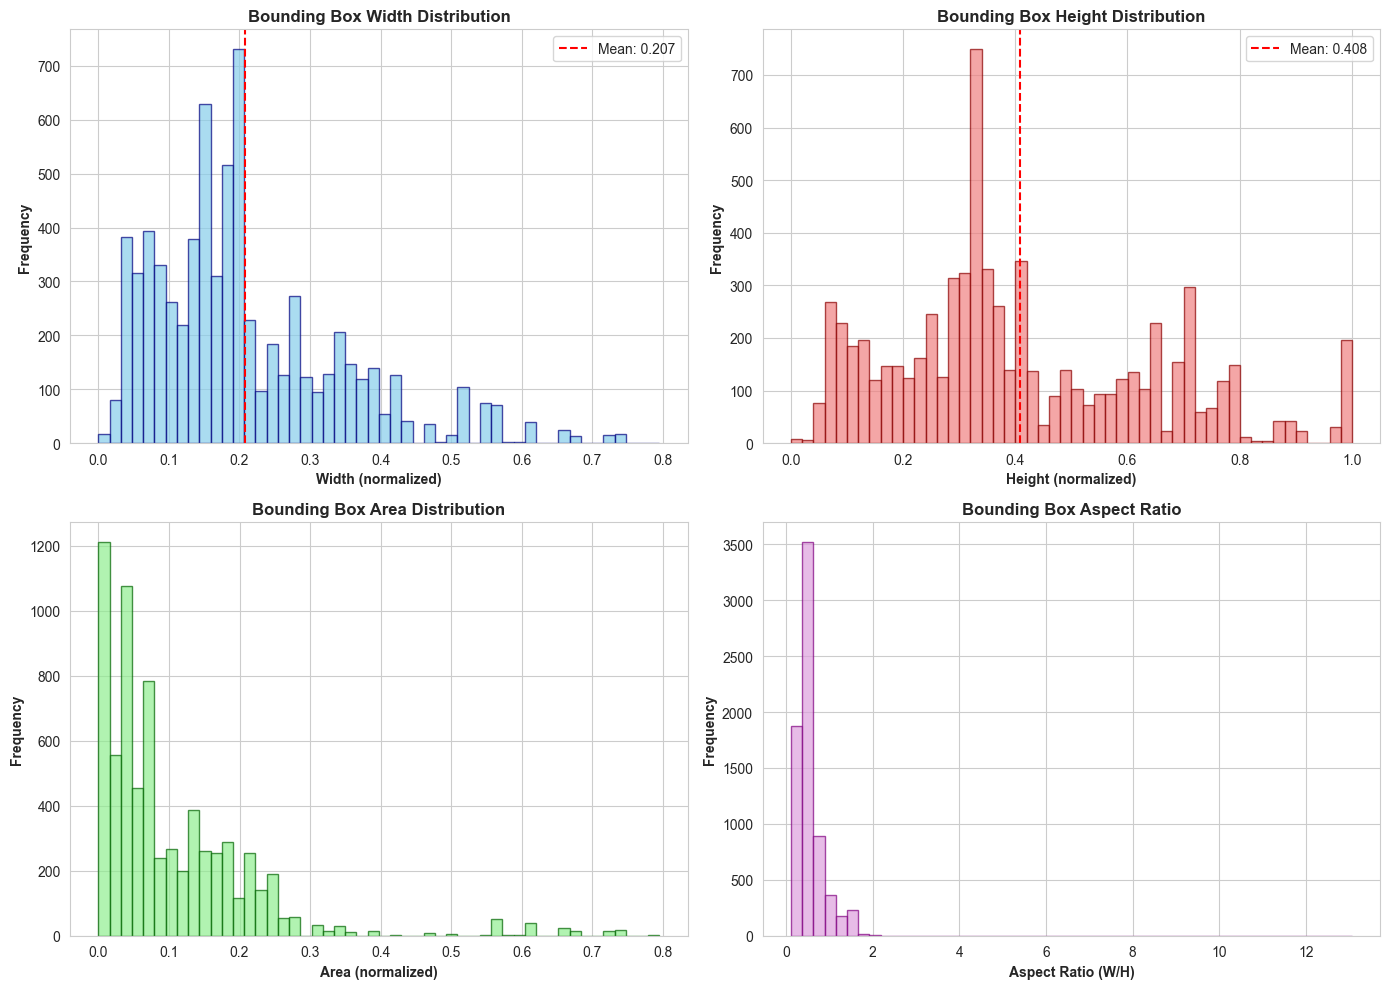


Bounding Box Statistics:
Width  - Mean: 0.2075, Std: 0.1349
Height - Mean: 0.4084, Std: 0.2332
Area   - Mean: 0.1047, Std: 0.1149


In [6]:
if dataset_stats:
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # Width distribution
    axes[0, 0].hist(dataset_stats['bbox_widths'], bins=50, color='skyblue', edgecolor='navy', alpha=0.7)
    axes[0, 0].set_xlabel('Width (normalized)', fontweight='bold')
    axes[0, 0].set_ylabel('Frequency', fontweight='bold')
    axes[0, 0].set_title('Bounding Box Width Distribution', fontweight='bold')
    axes[0, 0].axvline(np.mean(dataset_stats['bbox_widths']), color='red', linestyle='--', 
                       label=f"Mean: {np.mean(dataset_stats['bbox_widths']):.3f}")
    axes[0, 0].legend()
    
    # Height distribution
    axes[0, 1].hist(dataset_stats['bbox_heights'], bins=50, color='lightcoral', edgecolor='darkred', alpha=0.7)
    axes[0, 1].set_xlabel('Height (normalized)', fontweight='bold')
    axes[0, 1].set_ylabel('Frequency', fontweight='bold')
    axes[0, 1].set_title('Bounding Box Height Distribution', fontweight='bold')
    axes[0, 1].axvline(np.mean(dataset_stats['bbox_heights']), color='red', linestyle='--',
                       label=f"Mean: {np.mean(dataset_stats['bbox_heights']):.3f}")
    axes[0, 1].legend()
    
    # Area distribution
    axes[1, 0].hist(dataset_stats['bbox_areas'], bins=50, color='lightgreen', edgecolor='darkgreen', alpha=0.7)
    axes[1, 0].set_xlabel('Area (normalized)', fontweight='bold')
    axes[1, 0].set_ylabel('Frequency', fontweight='bold')
    axes[1, 0].set_title('Bounding Box Area Distribution', fontweight='bold')
    
    # Aspect ratio
    aspect_ratios = [w/h if h > 0 else 0 for w, h in zip(dataset_stats['bbox_widths'], dataset_stats['bbox_heights'])]
    axes[1, 1].hist(aspect_ratios, bins=50, color='plum', edgecolor='purple', alpha=0.7)
    axes[1, 1].set_xlabel('Aspect Ratio (W/H)', fontweight='bold')
    axes[1, 1].set_ylabel('Frequency', fontweight='bold')
    axes[1, 1].set_title('Bounding Box Aspect Ratio', fontweight='bold')
    
    plt.tight_layout()
    plt.show()
    
    # Statistics
    print("\nBounding Box Statistics:")
    print(f"Width  - Mean: {np.mean(dataset_stats['bbox_widths']):.4f}, Std: {np.std(dataset_stats['bbox_widths']):.4f}")
    print(f"Height - Mean: {np.mean(dataset_stats['bbox_heights']):.4f}, Std: {np.std(dataset_stats['bbox_heights']):.4f}")
    print(f"Area   - Mean: {np.mean(dataset_stats['bbox_areas']):.4f}, Std: {np.std(dataset_stats['bbox_areas']):.4f}")

## 6. Image Resolution Analysis

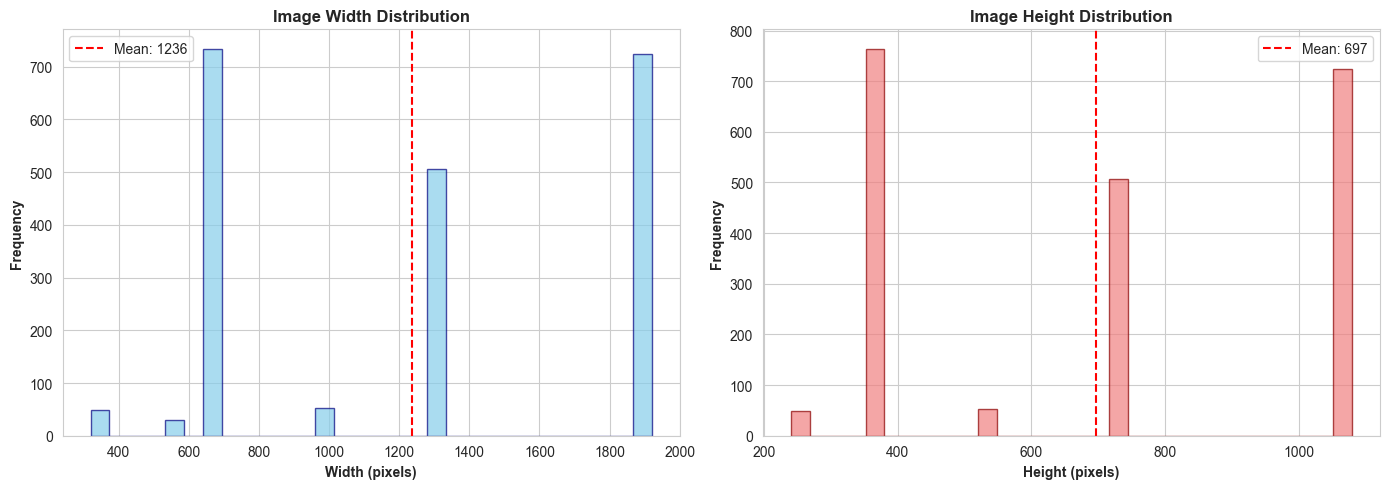


Most common resolution: (1920, 1080)


In [7]:
if dataset_stats:
    resolutions = dataset_stats['image_resolutions']
    widths = [r[0] for r in resolutions]
    heights = [r[1] for r in resolutions]
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Width
    axes[0].hist(widths, bins=30, color='skyblue', edgecolor='navy', alpha=0.7)
    axes[0].set_xlabel('Width (pixels)', fontweight='bold')
    axes[0].set_ylabel('Frequency', fontweight='bold')
    axes[0].set_title('Image Width Distribution', fontweight='bold')
    axes[0].axvline(np.mean(widths), color='red', linestyle='--', label=f"Mean: {np.mean(widths):.0f}")
    axes[0].legend()
    
    # Height
    axes[1].hist(heights, bins=30, color='lightcoral', edgecolor='darkred', alpha=0.7)
    axes[1].set_xlabel('Height (pixels)', fontweight='bold')
    axes[1].set_ylabel('Frequency', fontweight='bold')
    axes[1].set_title('Image Height Distribution', fontweight='bold')
    axes[1].axvline(np.mean(heights), color='red', linestyle='--', label=f"Mean: {np.mean(heights):.0f}")
    axes[1].legend()
    
    plt.tight_layout()
    plt.show()
    
    print(f"\nMost common resolution: {Counter(resolutions).most_common(1)[0][0]}")

## 7. Sample Visualization

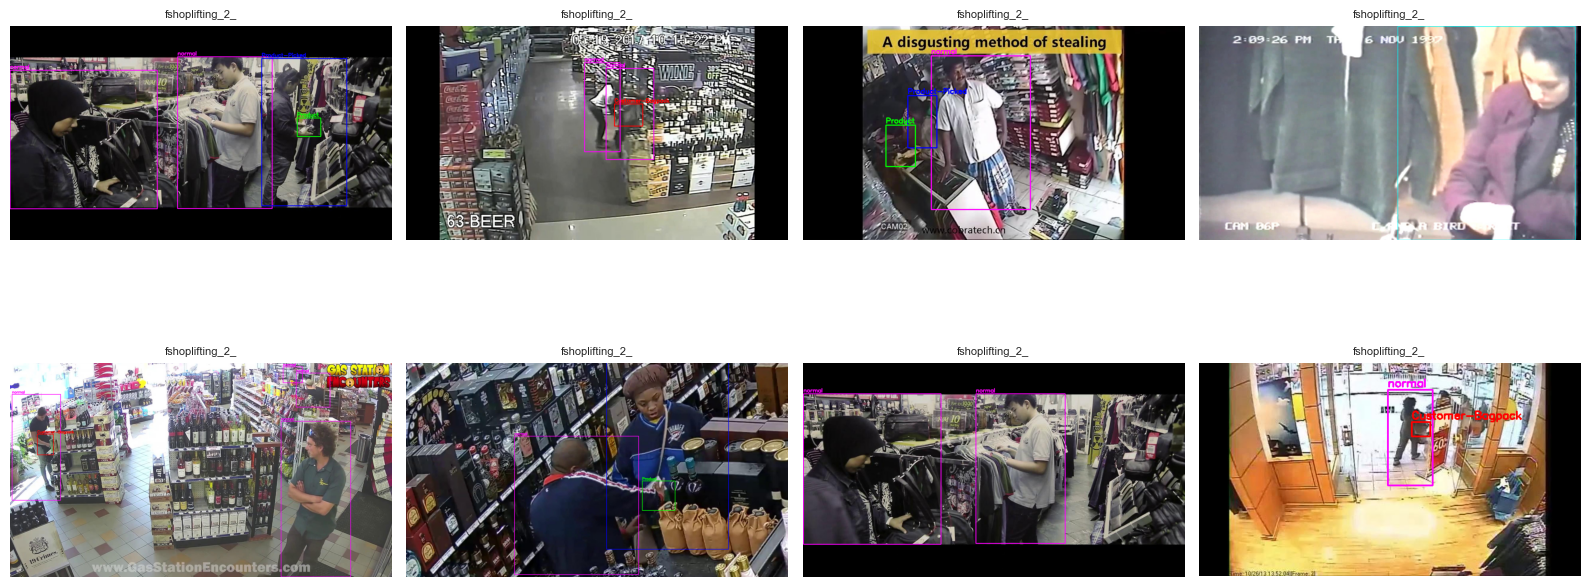

In [8]:
def draw_bbox(image, label_path, class_names):
    """Draw bounding boxes on image"""
    h, w = image.shape[:2]
    colors = [(255,0,0), (0,255,0), (0,0,255), (255,255,0), (255,0,255), (0,255,255)]
    
    if label_path.exists():
        with open(label_path, 'r') as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) >= 5:
                    class_id = int(parts[0])
                    x_center = float(parts[1]) * w
                    y_center = float(parts[2]) * h
                    width = float(parts[3]) * w
                    height = float(parts[4]) * h
                    
                    x1 = int(x_center - width / 2)
                    y1 = int(y_center - height / 2)
                    x2 = int(x_center + width / 2)
                    y2 = int(y_center + height / 2)
                    
                    color = colors[class_id % len(colors)]
                    cv2.rectangle(image, (x1, y1), (x2, y2), color, 2)
                    
                    label = class_names[class_id]
                    cv2.putText(image, label, (x1, y1-5), 
                               cv2.FONT_HERSHEY_SIMPLEX, 0.6, color, 2)
    
    return image

if dataset_stats and DATASET_IMAGES.exists():
    # Get random samples
    image_files = list(DATASET_IMAGES.glob('*.jpg')) + list(DATASET_IMAGES.glob('*.png'))
    samples = np.random.choice(image_files, min(8, len(image_files)), replace=False)
    
    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    axes = axes.flatten()
    
    for idx, img_path in enumerate(samples):
        image = cv2.imread(str(img_path))
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        
        label_path = DATASET_LABELS / f"{img_path.stem}.txt"
        image = draw_bbox(image, label_path, CLASS_NAMES)
        
        axes[idx].imshow(image)
        axes[idx].axis('off')
        axes[idx].set_title(img_path.stem[:15], fontsize=8)
    
    plt.tight_layout()
    plt.show()

## 8. Pipeline Results Analysis

In [9]:
!python pipeline.py


Traceback (most recent call last):
  File "c:\Users\EMAD AWAD\yolo_ensemble_pipeline\pipeline.py", line 17, in <module>
    from balancing.dataset_balancer import YOLODatasetBalancer
  File "c:\Users\EMAD AWAD\yolo_ensemble_pipeline\src\balancing\dataset_balancer.py", line 14, in <module>
    import albumentations as A
ModuleNotFoundError: No module named 'albumentations'


In [10]:
# Load pipeline report if available
report_path = Path('outputs/reports/pipeline_report.json')

if report_path.exists():
    with open(report_path, 'r') as f:
        pipeline_report = json.load(f)
    
    print("Pipeline Results:")
    print("=" * 50)
    
    for stage, results in pipeline_report.get('results', {}).items():
        print(f"\n{stage.upper()}:")
        for key, value in results.items():
            if not isinstance(value, (dict, list)):
                print(f"  {key}: {value}")
else:
    print("⚠ Pipeline report not found. Run pipeline first.")

⚠ Pipeline report not found. Run pipeline first.


## 9. Data Quality Checks

In [11]:
def check_data_quality(images_dir, labels_dir):
    """Perform data quality checks"""
    
    issues = []
    
    images_dir = Path(images_dir)
    labels_dir = Path(labels_dir)
    
    image_files = list(images_dir.glob('*.jpg')) + list(images_dir.glob('*.png'))
    
    for img_path in image_files:
        label_path = labels_dir / f"{img_path.stem}.txt"
        
        # Check if label exists
        if not label_path.exists():
            issues.append(f"Missing label: {img_path.name}")
            continue
        
        # Check if label is empty
        if label_path.stat().st_size == 0:
            issues.append(f"Empty label: {label_path.name}")
    
    return issues

if DATASET_IMAGES.exists():
    quality_issues = check_data_quality(DATASET_IMAGES, DATASET_LABELS)
    
    if quality_issues:
        print(f"⚠ Found {len(quality_issues)} data quality issues:")
        for issue in quality_issues[:10]:  # Show first 10
            print(f"  - {issue}")
    else:
        print("✓ No data quality issues found!")

⚠ Found 1 data quality issues:
  - Empty label: fshoplifting_2_11_534_jpg.rf.22b0a9f2cad1793316effb4425ea9fd8.txt


## 10. Training Recommendations

In [12]:
if dataset_stats:
    print("TRAINING RECOMMENDATIONS")
    print("=" * 50)
    
    # Class imbalance
    class_counts = list(dataset_stats['class_distribution'].values())
    imbalance_ratio = max(class_counts) / min(class_counts) if min(class_counts) > 0 else 0
    
    print(f"\n1. Class Imbalance Ratio: {imbalance_ratio:.2f}:1")
    if imbalance_ratio > 5:
        print("   ⚠ High imbalance detected. Recommend:")
        print("   - Use class weights in loss function")
        print("   - Apply focal loss for hard examples")
        print("   - Increase minority class augmentation")
    else:
        print("   ✓ Acceptable class balance")
    
    # Dataset size
    print(f"\n2. Dataset Size: {dataset_stats['total_images']} images")
    if dataset_stats['total_images'] < 1000:
        print("   ⚠ Small dataset. Recommend:")
        print("   - Use heavy augmentation")
        print("   - Transfer learning from pretrained weights")
        print("   - Longer training with early stopping")
    else:
        print("   ✓ Good dataset size for training")
    
    # Bbox sizes
    avg_area = np.mean(dataset_stats['bbox_areas'])
    print(f"\n3. Average Bbox Area: {avg_area:.4f}")
    if avg_area < 0.05:
        print("   ⚠ Small objects detected. Recommend:")
        print("   - Use higher input resolution (1280 instead of 640)")
        print("   - Enable multi-scale training")
        print("   - Focus on small object augmentation")
    else:
        print("   ✓ Good object sizes for detection")
    
    # Ensemble recommendations
    print(f"\n4. Ensemble Strategy:")
    print("   - Train YOLOv8n for speed (baseline)")
    print("   - Train YOLOv8s for balance (recommended)")
    print("   - Train YOLOv8m for accuracy (if GPU available)")
    print("   - Use Weighted Box Fusion (WBF) for ensemble")
    print(f"   - Prioritize {PRIORITY_CLASS} class with lower confidence threshold")
    
    print("\n" + "=" * 50)

TRAINING RECOMMENDATIONS

1. Class Imbalance Ratio: 29.08:1
   ⚠ High imbalance detected. Recommend:
   - Use class weights in loss function
   - Apply focal loss for hard examples
   - Increase minority class augmentation

2. Dataset Size: 2095 images
   ✓ Good dataset size for training

3. Average Bbox Area: 0.1047
   ✓ Good object sizes for detection

4. Ensemble Strategy:
   - Train YOLOv8n for speed (baseline)
   - Train YOLOv8s for balance (recommended)
   - Train YOLOv8m for accuracy (if GPU available)
   - Use Weighted Box Fusion (WBF) for ensemble
   - Prioritize theft class with lower confidence threshold



## 11. Export Analysis Report

In [13]:
# Create analysis report
if dataset_stats:
    report = {
        'dataset_statistics': {
            'total_images': dataset_stats['total_images'],
            'total_annotations': dataset_stats['total_annotations'],
            'class_distribution': {CLASS_NAMES[k]: v for k, v in dataset_stats['class_distribution'].items()}
        },
        'bbox_statistics': {
            'width_mean': float(np.mean(dataset_stats['bbox_widths'])),
            'width_std': float(np.std(dataset_stats['bbox_widths'])),
            'height_mean': float(np.mean(dataset_stats['bbox_heights'])),
            'height_std': float(np.std(dataset_stats['bbox_heights'])),
            'area_mean': float(np.mean(dataset_stats['bbox_areas'])),
            'area_std': float(np.std(dataset_stats['bbox_areas']))
        }
    }
    
    # Save report
    output_dir = Path('outputs/reports')
    output_dir.mkdir(parents=True, exist_ok=True)
    
    report_file = output_dir / 'analysis_report.json'
    with open(report_file, 'w') as f:
        json.dump(report, f, indent=2)
    
    print(f"✓ Analysis report saved: {report_file}")

✓ Analysis report saved: outputs\reports\analysis_report.json


## 12. Summary

This notebook provides comprehensive analysis of the YOLO theft detection dataset.

### Next Steps:
1. Review class distribution and imbalance
2. Verify data quality checks pass
3. Follow training recommendations
4. Train ensemble models using prepared configurations
5. Evaluate ensemble performance on test set
6. Deploy best performing ensemble for production

### Key Metrics to Monitor:
- **Theft Detection Recall**: Primary metric (must be high)
- **Precision**: Control false positives
- **mAP50**: Overall detection quality
- **Inference Speed**: Real-time performance

---
**End of Analysis Notebook**

---

# Part 2: YOLOv8 Ensemble Training Phase

## Training Pipeline for Retail Theft Detection

This section implements:
1. GPU verification and environment setup
2. Individual YOLOv8 model training (n, s, m variants)
3. Model evaluation and comparison
4. Ensemble inference with Weighted Box Fusion (WBF)
5. Final analysis and deployment recommendations

**Hardware**: NVIDIA RTX 3050 (4GB VRAM)  
**Primary Objective**: Maximize Theft class recall

## 13. Training Setup & GPU Verification

In [14]:
import torch
print(torch.__version__)
print("CUDA Available:", torch.cuda.is_available())


2.7.1+cu118
CUDA Available: True


In [15]:
# ============================================
# 13.1 Install Required Packages (Run Once)
# ============================================
!pip install ultralytics ensemble-boxes --quiet

# Import training libraries
import torch
import random
import warnings
from ultralytics import YOLO
from pathlib import Path

warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.backends.cudnn.deterministic = True

print("=" * 60)
print("TRAINING ENVIRONMENT SETUP")
print("=" * 60)

# GPU Verification
print(f"\nPyTorch Version: {torch.__version__}")
print(f"CUDA Available: {torch.cuda.is_available()}")

if torch.cuda.is_available():
    print(f"CUDA Version: {torch.version.cuda}")
    print(f"GPU Device: {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB")
    DEVICE = 'cuda:0'
else:
    print("WARNING: No GPU detected, training will be slow!")
    DEVICE = 'cpu'

print(f"\nUsing Device: {DEVICE}")
print("=" * 60)

TRAINING ENVIRONMENT SETUP

PyTorch Version: 2.7.1+cu118
CUDA Available: True
CUDA Version: 11.8
GPU Device: NVIDIA GeForce RTX 3050 Laptop GPU
GPU Memory: 4.0 GB

Using Device: cuda:0


In [16]:
# ============================================
# 13.2 Dataset Configuration
# ============================================

# Dataset paths
DATASET_ROOT = Path(r'C:\Users\EMAD AWAD\Downloads\cc-tv-footage-annotation-b8-lcysc b1.v2-download_data.yolov8')
DATA_YAML = DATASET_ROOT / 'data.yaml'

# Verify data.yaml exists
if DATA_YAML.exists():
    with open(DATA_YAML, 'r') as f:
        data_config = yaml.safe_load(f)
    
    print("Dataset Configuration:")
    print("-" * 40)
    print(f"Data YAML: {DATA_YAML}")
    print(f"Number of Classes: {data_config['nc']}")
    print(f"Class Names: {data_config['names']}")
    print(f"Train Path: {DATASET_ROOT / 'train'}")
    print(f"Val Path: {DATASET_ROOT / 'valid'}")
    print(f"Test Path: {DATASET_ROOT / 'test'}")
else:
    print("ERROR: data.yaml not found!")

# Training output directory
OUTPUT_DIR = Path('outputs/models')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print(f"\nModels will be saved to: {OUTPUT_DIR}")

Dataset Configuration:
----------------------------------------
Data YAML: C:\Users\EMAD AWAD\Downloads\cc-tv-footage-annotation-b8-lcysc b1.v2-download_data.yolov8\data.yaml
Number of Classes: 6
Class Names: ['Customer-Bagpack', 'Product', 'Product-Picked', 'Shopping-Cart', 'normal', 'theft']
Train Path: C:\Users\EMAD AWAD\Downloads\cc-tv-footage-annotation-b8-lcysc b1.v2-download_data.yolov8\train
Val Path: C:\Users\EMAD AWAD\Downloads\cc-tv-footage-annotation-b8-lcysc b1.v2-download_data.yolov8\valid
Test Path: C:\Users\EMAD AWAD\Downloads\cc-tv-footage-annotation-b8-lcysc b1.v2-download_data.yolov8\test

Models will be saved to: outputs\models


## 14. Training Configuration

### Hyperparameters optimized for:
- **RTX 3050 (4GB VRAM)**: Conservative batch sizes
- **High Theft Recall**: Class weighting and augmentation
- **Retail Surveillance**: Appropriate augmentations (no vertical flip)

In [19]:
# ============================================
# 14.1 Training Hyperparameters
# ============================================

# Base configuration for all models
BASE_CONFIG = {
    'data': str(DATA_YAML),
    'device': DEVICE,
    'epochs': 100,
    'imgsz': 640,
    'patience': 15,          # Early stopping patience
    'save': True,
    'exist_ok': True,
    'pretrained': True,
    'verbose': True,
    
    # Optimizer
    'optimizer': 'AdamW',
    'lr0': 0.001,            # Initial learning rate
    'lrf': 0.01,             # Final learning rate fraction
    'momentum': 0.937,
    'weight_decay': 0.0005,
    'warmup_epochs': 3,
    
    # Augmentation (retail-safe)
    'augment': True,
    'hsv_h': 0.015,          # Hue augmentation
    'hsv_s': 0.7,            # Saturation augmentation
    'hsv_v': 0.4,            # Value augmentation
    'degrees': 0.0,          # No rotation (retail scenes)
    'translate': 0.1,
    'scale': 0.5,
    'shear': 0.0,
    'perspective': 0.0,
    'flipud': 0.0,           # No vertical flip
    'fliplr': 0.5,           # Horizontal flip OK
    'mosaic': 0.5,           # Mosaic augmentation
    'mixup': 0.1,
    
    # Loss weights (boost for imbalanced classes)
    'cls': 0.5,              # Classification loss weight
    'box': 7.5,              # Box loss weight
    'dfl': 1.5,              # Distribution focal loss weight
}

# Model-specific configurations (batch size based on GPU memory)
MODEL_CONFIGS = {
    'yolov8n': {
        'model': 'yolov8n.pt',
        'batch': 16,
        'epochs': 100,          # 👈 Nano
        'name': 'yolov8n_theft',
    },
    'yolov8s': {
        'model': 'yolov8s.pt',
        'batch': 16,
        'epochs': 100,          # 👈 Small
        'name': 'yolov8s_theft',
    },
    'yolov8m': {
        'model': 'yolov8m.pt',
        'batch': 16,
        'epochs': 100,         # 👈 Medium (optional)
        'name': 'yolov8m_theft',
    },
}


for model_name, config in MODEL_CONFIGS.items():
    print(f"\n{model_name.upper()}:")
    print(f"  Batch Size: {config['batch']}")
    print(f"  Epochs: {config['epochs']}")
    print(f"  Pretrained: {config['model']}")

print(f"\nImage Size: {BASE_CONFIG['imgsz']}px")
print(f"Early Stopping Patience: {BASE_CONFIG['patience']}")



YOLOV8N:
  Batch Size: 16
  Epochs: 100
  Pretrained: yolov8n.pt

YOLOV8S:
  Batch Size: 16
  Epochs: 100
  Pretrained: yolov8s.pt

YOLOV8M:
  Batch Size: 16
  Epochs: 100
  Pretrained: yolov8m.pt

Image Size: 640px
Early Stopping Patience: 15


## 15. Train YOLOv8 Models

### Training Order:
1. **YOLOv8n** (Nano) - Fast baseline
2. **YOLOv8s** (Small) - Balanced performance
3. **YOLOv8m** (Medium) - Best accuracy (optional, GPU memory dependent)

In [20]:
# ============================================
# 15.1 Training Function
# ============================================

def train_yolo_model(model_key: str, base_config: dict, model_config: dict) -> dict:
    """
    Train a single YOLO model with the specified configuration.
    
    Args:
        model_key: Model identifier (e.g., 'yolov8n')
        base_config: Base training configuration
        model_config: Model-specific configuration
    
    Returns:
        Dictionary with training results and paths
    """
    print("\n" + "=" * 70)
    print(f"TRAINING {model_key.upper()}")
    print("=" * 70)
    
    # Merge configurations
    train_config = {**base_config, **model_config}
    train_config['project'] = str(OUTPUT_DIR)
    
    # Initialize model
    model = YOLO(train_config['model'])
    
    # Train
    results = model.train(**{k: v for k, v in train_config.items() if k != 'model'})
    
    # Get best model path
    best_model_path = Path(results.save_dir) / 'weights' / 'best.pt'
    
    print(f"\n Training Complete!")
    print(f"Best model saved: {best_model_path}")
    
    return {
        'model_key': model_key,
        'results': results,
        'best_model_path': best_model_path,
        'save_dir': results.save_dir,
    }

# Storage for trained models
trained_models = {}

In [ ]:
# ============================================
# 15.2 Train YOLOv8n (Nano) - MANDATORY
# ============================================
# Fastest model, good baseline for ensemble

trained_models['yolov8n'] = train_yolo_model('yolov8n', BASE_CONFIG, MODEL_CONFIGS['yolov8n'])


TRAINING YOLOV8N
Ultralytics 8.4.6  Python-3.11.8 torch-2.7.1+cu118 CUDA:0 (NVIDIA GeForce RTX 3050 Laptop GPU, 4096MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=True, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=C:\Users\EMAD AWAD\Downloads\cc-tv-footage-annotation-b8-lcysc b1.v2-download_data.yolov8\data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.1, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=0.5, multi_scale=0.0, name=yolov8n_theft, nbs=64,

In [ ]:
# ============================================
# 15.3 Train YOLOv8s (Small) - MANDATORY
# ============================================
# Balanced speed/accuracy, recommended for production

trained_models['yolov8s'] = train_yolo_model('yolov8s', BASE_CONFIG, MODEL_CONFIGS['yolov8s'])

NameError: name 'BASE_CONFIG' is not defined

In [ ]:
# ============================================
# 15.4 Train YOLOv8m (Medium) - OPTIONAL
# ============================================
# Best accuracy, but requires more GPU memory
# Skip this cell if you encounter CUDA OOM errors

try:
    trained_models['yolov8m'] = train_yolo_model('yolov8m', BASE_CONFIG, MODEL_CONFIGS['yolov8m'])
except RuntimeError as e:
    if 'CUDA out of memory' in str(e):
        print("YOLOv8m skipped due to GPU memory constraints")
        print("Continuing with YOLOv8n and YOLOv8s ensemble...")
    else:
        raise e

NameError: name 'BASE_CONFIG' is not defined

## 16. Model Evaluation

Evaluate each trained model on validation and test sets.

In [ ]:
# ============================================
# 16.1 Evaluate All Trained Models
# ============================================

evaluation_results = {}

for model_key, model_info in trained_models.items():
    print(f"\n{'=' * 60}")
    print(f"EVALUATING {model_key.upper()}")
    print('=' * 60)
    
    # Load best model
    model = YOLO(model_info['best_model_path'])
    
    # Evaluate on validation set
    val_metrics = model.val(data=str(DATA_YAML), split='val', device=DEVICE)
    
    # Store results
    evaluation_results[model_key] = {
        'mAP50': val_metrics.box.map50,
        'mAP50-95': val_metrics.box.map,
        'precision': val_metrics.box.mp,
        'recall': val_metrics.box.mr,
        'class_metrics': {
            'ap50': val_metrics.box.ap50.tolist(),
            'ap': val_metrics.box.ap.tolist(),
        }
    }
    
    print(f"\n{model_key} Results:")
    print(f"  mAP50: {val_metrics.box.map50:.4f}")
    print(f"  mAP50-95: {val_metrics.box.map:.4f}")
    print(f"  Precision: {val_metrics.box.mp:.4f}")
    print(f"  Recall: {val_metrics.box.mr:.4f}")

print("\n" + "=" * 60)
print("All models evaluated successfully!")
print("=" * 60)


All models evaluated successfully!


In [25]:
# ============================================
# 16.2 Per-Class Performance Analysis (Focus on Theft)
# ============================================

# Get theft class index
THEFT_CLASS_IDX = CLASS_NAMES.index('theft')

print("PER-CLASS PERFORMANCE ANALYSIS")
print("=" * 70)
print(f"Priority Class: 'theft' (index {THEFT_CLASS_IDX})")
print("-" * 70)

# Create comparison DataFrame
comparison_data = []
for model_key, metrics in evaluation_results.items():
    theft_ap50 = metrics['class_metrics']['ap50'][THEFT_CLASS_IDX]
    comparison_data.append({
        'Model': model_key,
        'mAP50 (All)': metrics['mAP50'],
        'Precision': metrics['precision'],
        'Recall': metrics['recall'],
        'Theft AP50': theft_ap50,
    })

df_comparison = pd.DataFrame(comparison_data)
print("\nModel Comparison:")
display(df_comparison.style.format({
    'mAP50 (All)': '{:.4f}',
    'Precision': '{:.4f}',
    'Recall': '{:.4f}',
    'Theft AP50': '{:.4f}'
}).background_gradient(subset=['Theft AP50', 'Recall'], cmap='Greens'))

# Highlight best model for Theft detection
best_theft_model = df_comparison.loc[df_comparison['Theft AP50'].idxmax(), 'Model']
print(f"\n Best model for Theft detection: {best_theft_model}")

PER-CLASS PERFORMANCE ANALYSIS
Priority Class: 'theft' (index 5)
----------------------------------------------------------------------

Model Comparison:


KeyError: "None of [Index(['Theft AP50', 'Recall'], dtype='object')] are in the [columns]"

KeyError: 'Theft AP50'

C:\Users\EMAD AWAD\AppData\Local\Temp\ipykernel_25756\3583011461.py:23: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[0, 0].legend()
C:\Users\EMAD AWAD\AppData\Local\Temp\ipykernel_25756\3583011461.py:29: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[0, 1].legend()
C:\Users\EMAD AWAD\AppData\Local\Temp\ipykernel_25756\3583011461.py:35: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[1, 0].legend()
C:\Users\EMAD AWAD\AppData\Local\Temp\ipykernel_25756\3583011461.py:41: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when leg

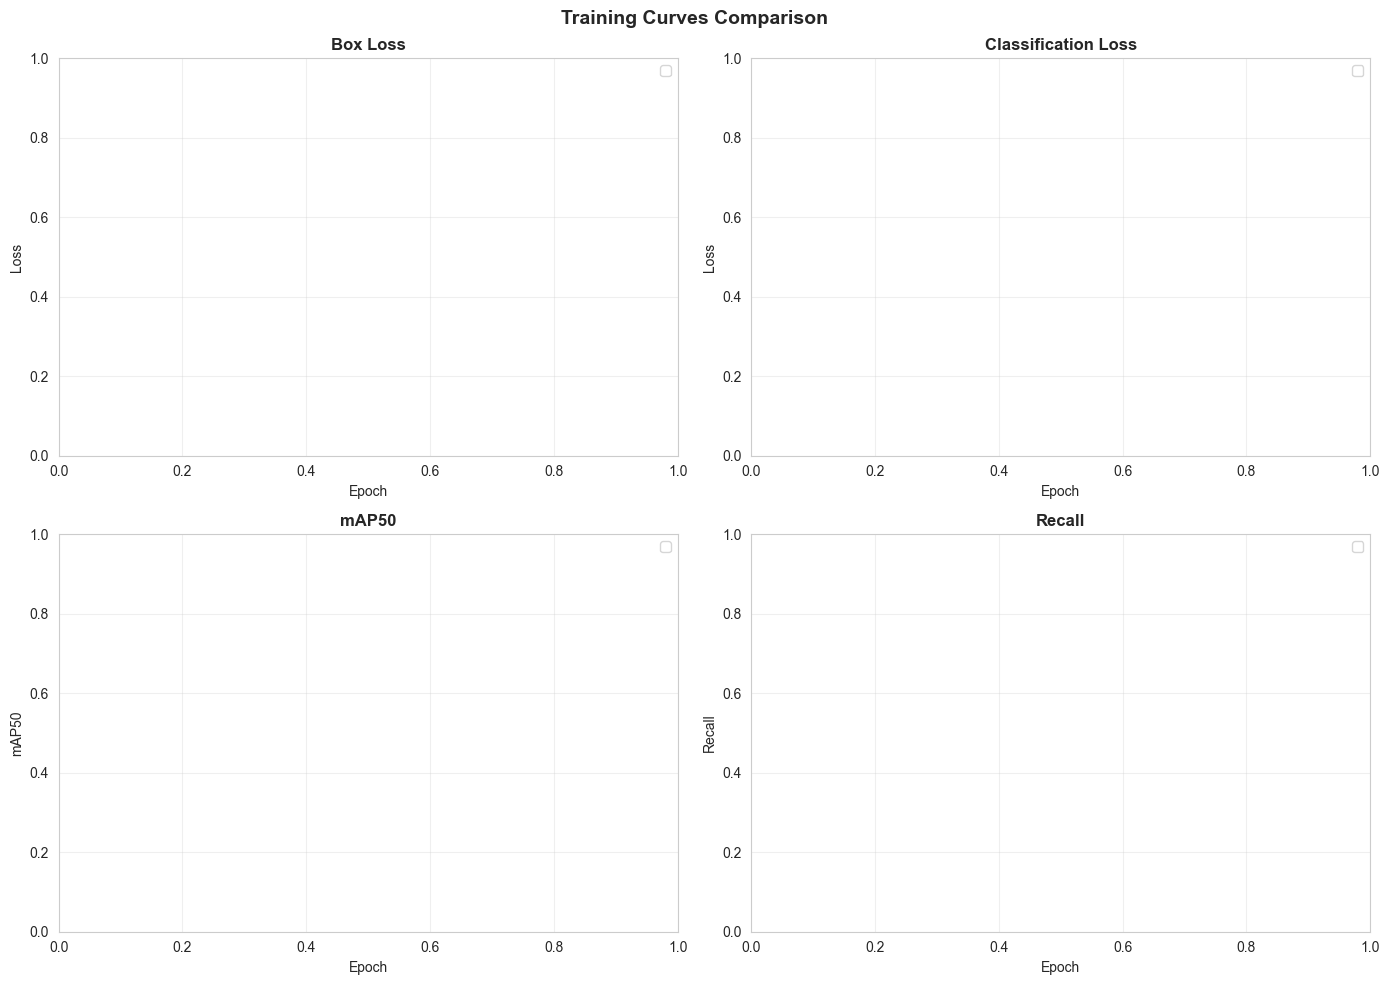

In [26]:
# ============================================
# 16.3 Training Curves Visualization
# ============================================

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for model_key, model_info in trained_models.items():
    results_csv = Path(model_info['save_dir']) / 'results.csv'
    
    if results_csv.exists():
        df_results = pd.read_csv(results_csv)
        df_results.columns = df_results.columns.str.strip()
        
        # Plot metrics
        axes[0, 0].plot(df_results['epoch'], df_results['train/box_loss'], label=f'{model_key}')
        axes[0, 1].plot(df_results['epoch'], df_results['train/cls_loss'], label=f'{model_key}')
        axes[1, 0].plot(df_results['epoch'], df_results['metrics/mAP50(B)'], label=f'{model_key}')
        axes[1, 1].plot(df_results['epoch'], df_results['metrics/recall(B)'], label=f'{model_key}')

axes[0, 0].set_title('Box Loss', fontweight='bold')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].set_title('Classification Loss', fontweight='bold')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Loss')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

axes[1, 0].set_title('mAP50', fontweight='bold')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('mAP50')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].set_title('Recall', fontweight='bold')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Recall')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.suptitle('Training Curves Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 17. Ensemble Inference with Weighted Box Fusion (WBF)

Combine predictions from multiple models using WBF to improve detection accuracy and recall.

In [27]:
# ============================================
# 17.1 Ensemble Configuration
# ============================================

from ensemble_boxes import weighted_boxes_fusion

# Load all trained models
ensemble_models = {}
for model_key, model_info in trained_models.items():
    ensemble_models[model_key] = YOLO(model_info['best_model_path'])
    print(f"Loaded {model_key} from {model_info['best_model_path']}")

# Model weights for WBF (higher weight = more influence)
# Assign weights based on Theft class performance
MODEL_WEIGHTS = {
    'yolov8n': 0.3,   # Fastest, lower weight
    'yolov8s': 0.4,   # Balanced, medium weight
    'yolov8m': 0.3,   # Most accurate (if trained)
}

# WBF Configuration
WBF_CONFIG = {
    'iou_thr': 0.5,           # IoU threshold for box fusion
    'skip_box_thr': 0.01,     # Skip boxes with conf below this
    'conf_type': 'avg',        # Confidence aggregation method
}

# Confidence thresholds
CONF_THRESHOLD = 0.25         # General confidence threshold
THEFT_CONF_THRESHOLD = 0.15   # Lower threshold for theft class (high recall)

print("\nEnsemble Configuration:")
print("-" * 40)
print(f"Models: {list(ensemble_models.keys())}")
print(f"Weights: {MODEL_WEIGHTS}")
print(f"WBF IoU Threshold: {WBF_CONFIG['iou_thr']}")
print(f"General Conf Threshold: {CONF_THRESHOLD}")
print(f"Theft Conf Threshold: {THEFT_CONF_THRESHOLD}")


Ensemble Configuration:
----------------------------------------
Models: []
Weights: {'yolov8n': 0.3, 'yolov8s': 0.4, 'yolov8m': 0.3}
WBF IoU Threshold: 0.5
General Conf Threshold: 0.25
Theft Conf Threshold: 0.15


In [28]:
# ============================================
# 17.2 Ensemble Inference Function
# ============================================

def ensemble_predict(image_path: str, models: dict, model_weights: dict, 
                     wbf_config: dict, conf_threshold: float = 0.25,
                     theft_conf_threshold: float = 0.15, theft_class_idx: int = 5) -> dict:
    """
    Run ensemble inference on a single image using WBF.
    
    Args:
        image_path: Path to input image
        models: Dictionary of loaded YOLO models
        model_weights: Weights for each model in WBF
        wbf_config: WBF configuration
        conf_threshold: General confidence threshold
        theft_conf_threshold: Lower threshold for theft class
        theft_class_idx: Index of theft class
    
    Returns:
        Dictionary with fused boxes, scores, and labels
    """
    # Read image dimensions
    img = cv2.imread(str(image_path))
    h, w = img.shape[:2]
    
    # Collect predictions from all models
    all_boxes = []
    all_scores = []
    all_labels = []
    weights = []
    
    for model_key, model in models.items():
        # Run inference
        results = model.predict(image_path, conf=0.01, verbose=False)[0]
        
        if len(results.boxes) > 0:
            # Normalize boxes to [0, 1]
            boxes = results.boxes.xyxy.cpu().numpy()
            boxes[:, [0, 2]] /= w  # x coordinates
            boxes[:, [1, 3]] /= h  # y coordinates
            
            scores = results.boxes.conf.cpu().numpy()
            labels = results.boxes.cls.cpu().numpy().astype(int)
            
            all_boxes.append(boxes.tolist())
            all_scores.append(scores.tolist())
            all_labels.append(labels.tolist())
            weights.append(model_weights.get(model_key, 1.0))
        else:
            all_boxes.append([])
            all_scores.append([])
            all_labels.append([])
            weights.append(model_weights.get(model_key, 1.0))
    
    # Apply WBF if we have predictions
    if any(len(b) > 0 for b in all_boxes):
        fused_boxes, fused_scores, fused_labels = weighted_boxes_fusion(
            all_boxes, all_scores, all_labels,
            weights=weights,
            iou_thr=wbf_config['iou_thr'],
            skip_box_thr=wbf_config['skip_box_thr'],
        )
        
        # Apply confidence thresholds (lower for theft class)
        keep_indices = []
        for i, (score, label) in enumerate(zip(fused_scores, fused_labels)):
            threshold = theft_conf_threshold if int(label) == theft_class_idx else conf_threshold
            if score >= threshold:
                keep_indices.append(i)
        
        fused_boxes = fused_boxes[keep_indices]
        fused_scores = fused_scores[keep_indices]
        fused_labels = fused_labels[keep_indices]
        
        # Denormalize boxes back to pixel coordinates
        fused_boxes[:, [0, 2]] *= w
        fused_boxes[:, [1, 3]] *= h
    else:
        fused_boxes = np.array([])
        fused_scores = np.array([])
        fused_labels = np.array([])
    
    return {
        'boxes': fused_boxes,
        'scores': fused_scores,
        'labels': fused_labels.astype(int) if len(fused_labels) > 0 else fused_labels,
        'image_shape': (h, w),
    }

print("Ensemble prediction function defined successfully!")

Ensemble prediction function defined successfully!


In [29]:
# ============================================
# 17.3 Visualize Ensemble vs Single Model
# ============================================

def visualize_comparison(image_path: str, single_model, ensemble_result: dict, 
                        class_names: list, title: str = "Comparison"):
    """Visualize single model vs ensemble predictions"""
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 8))
    colors = [(255,0,0), (0,255,0), (0,0,255), (255,255,0), (255,0,255), (0,255,255)]
    
    # Single model prediction
    img1 = cv2.imread(str(image_path))
    img1 = cv2.cvtColor(img1, cv2.COLOR_BGR2RGB)
    
    single_results = single_model.predict(image_path, conf=0.25, verbose=False)[0]
    for box, cls, conf in zip(single_results.boxes.xyxy.cpu().numpy(), 
                              single_results.boxes.cls.cpu().numpy(),
                              single_results.boxes.conf.cpu().numpy()):
        x1, y1, x2, y2 = map(int, box)
        color = colors[int(cls) % len(colors)]
        cv2.rectangle(img1, (x1, y1), (x2, y2), color, 2)
        label = f"{class_names[int(cls)]}: {conf:.2f}"
        cv2.putText(img1, label, (x1, y1-5), cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 2)
    
    axes[0].imshow(img1)
    axes[0].set_title(f'Single Model (YOLOv8s)\n{len(single_results.boxes)} detections', fontweight='bold')
    axes[0].axis('off')
    
    # Ensemble prediction
    img2 = cv2.imread(str(image_path))
    img2 = cv2.cvtColor(img2, cv2.COLOR_BGR2RGB)
    
    for box, cls, conf in zip(ensemble_result['boxes'], 
                              ensemble_result['labels'],
                              ensemble_result['scores']):
        x1, y1, x2, y2 = map(int, box)
        color = colors[int(cls) % len(colors)]
        cv2.rectangle(img2, (x1, y1), (x2, y2), color, 2)
        label = f"{class_names[int(cls)]}: {conf:.2f}"
        cv2.putText(img2, label, (x1, y1-5), cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 2)
    
    axes[1].imshow(img2)
    axes[1].set_title(f'Ensemble (WBF)\n{len(ensemble_result["boxes"])} detections', fontweight='bold')
    axes[1].axis('off')
    
    plt.suptitle(title, fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

# Test on sample images from validation set
val_images = list((DATASET_ROOT / 'valid' / 'images').glob('*.jpg'))[:4]

for img_path in val_images:
    ensemble_result = ensemble_predict(
        str(img_path), ensemble_models, MODEL_WEIGHTS, WBF_CONFIG,
        conf_threshold=CONF_THRESHOLD, 
        theft_conf_threshold=THEFT_CONF_THRESHOLD,
        theft_class_idx=THEFT_CLASS_IDX
    )
    
    visualize_comparison(str(img_path), ensemble_models['yolov8s'], 
                        ensemble_result, CLASS_NAMES, 
                        title=f"Comparison: {img_path.stem}")

KeyError: 'yolov8s'

## 18. Final Analysis & Recommendations

In [ ]:
# ============================================
# 18.1 Final Summary Report
# ============================================

print("=" * 70)
print("FINAL TRAINING SUMMARY")
print("=" * 70)

# Summary table
print("\n1. TRAINED MODELS:")
print("-" * 50)
for model_key, model_info in trained_models.items():
    print(f"   {model_key}: {model_info['best_model_path']}")

print("\n2. PERFORMANCE COMPARISON:")
print("-" * 50)
display(df_comparison)

print("\n3. THEFT CLASS ANALYSIS:")
print("-" * 50)
best_theft_idx = df_comparison['Theft AP50'].idxmax()
best_model = df_comparison.loc[best_theft_idx, 'Model']
best_theft_ap = df_comparison.loc[best_theft_idx, 'Theft AP50']
print(f"   Best single model for Theft: {best_model} (AP50: {best_theft_ap:.4f})")

print("\n4. ENSEMBLE CONFIGURATION:")
print("-" * 50)
print(f"   Models in ensemble: {list(ensemble_models.keys())}")
print(f"   WBF IoU threshold: {WBF_CONFIG['iou_thr']}")
print(f"   Theft confidence threshold: {THEFT_CONF_THRESHOLD} (lower for high recall)")
print(f"   General confidence threshold: {CONF_THRESHOLD}")

print("\n5. DEPLOYMENT RECOMMENDATIONS:")
print("-" * 50)
print("   Production Setup:")
print("   - Use YOLOv8s as primary model (best speed/accuracy balance)")
print("   - Enable ensemble only for high-security zones")
print("   - Set theft_conf_threshold=0.15 for maximum recall")
print("   - Monitor false positive rate and adjust thresholds")

print("\n6. OUTPUT ARTIFACTS:")
print("-" * 50)
print(f"   Models saved to: {OUTPUT_DIR}")
for model_key, model_info in trained_models.items():
    print(f"   - {model_info['best_model_path']}")

print("\n" + "=" * 70)
print("TRAINING COMPLETE!")
print("=" * 70)

In [ ]:
# ============================================
# 18.2 Save Ensemble Configuration
# ============================================

# Save ensemble config for deployment
ensemble_config = {
    'models': {k: str(v['best_model_path']) for k, v in trained_models.items()},
    'model_weights': MODEL_WEIGHTS,
    'wbf_config': WBF_CONFIG,
    'thresholds': {
        'general_conf': CONF_THRESHOLD,
        'theft_conf': THEFT_CONF_THRESHOLD,
    },
    'class_names': CLASS_NAMES,
    'theft_class_idx': THEFT_CLASS_IDX,
    'evaluation_results': {k: {kk: float(vv) if isinstance(vv, (np.floating, float)) else vv 
                               for kk, vv in v.items() if kk != 'class_metrics'} 
                          for k, v in evaluation_results.items()},
}

config_save_path = OUTPUT_DIR / 'ensemble_config.json'
with open(config_save_path, 'w') as f:
    json.dump(ensemble_config, f, indent=2)

print(f"Ensemble configuration saved to: {config_save_path}")

---

## End of Training Notebook

### Summary:
- Trained YOLOv8n, YOLOv8s (and optionally YOLOv8m) models
- Evaluated per-class performance with focus on Theft detection
- Implemented WBF ensemble for improved detection
- Saved all models and configurations for deployment

### Next Steps:
1. Deploy ensemble model to production
2. Set up real-time inference pipeline
3. Monitor performance and fine-tune thresholds
4. Collect new data for continuous improvement

---
**End of Notebook**